<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Image Segmentation</b>
</h1>
<div style="font-family:'Times New Roman';">
Segmentation means splitting an image into meaningful regions. A few diffrent ways here: by intensity (thresholding), by edges (Canny), by region (Otsu + morphology + distance transform), and by colour (k means on the pixels).
</div>

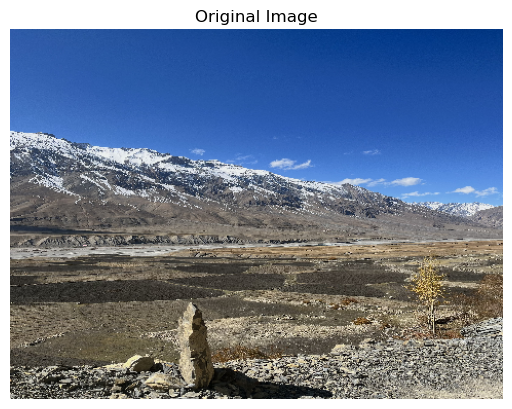

shape (360, 480, 3)  dtype uint8  min 0  max 255


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# load my own photo and shrink it, the original is huge (4032x3024)
img = cv2.imread('image.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (480, 360))

plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.show()
print('shape', img.shape, ' dtype', img.dtype, ' min', img.min(), ' max', img.max())

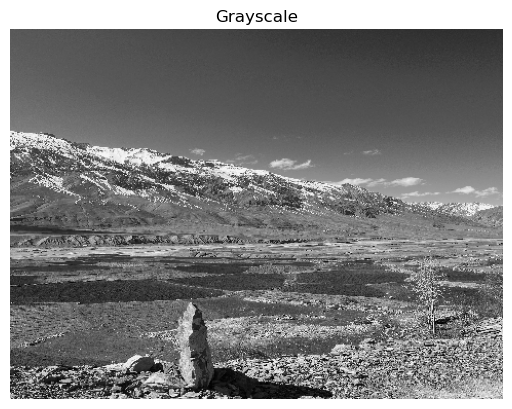

In [2]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap='gray'); plt.title('Grayscale'); plt.axis('off'); plt.show()

## thresholding

the simplest idea, every pixel brighter than a cutoff becomes white, the rest black. a **fixed** cutoff is manual, **Otsu** picks the cutoff automaticaly from the histogram.

otsu picked the cutoff 123.0


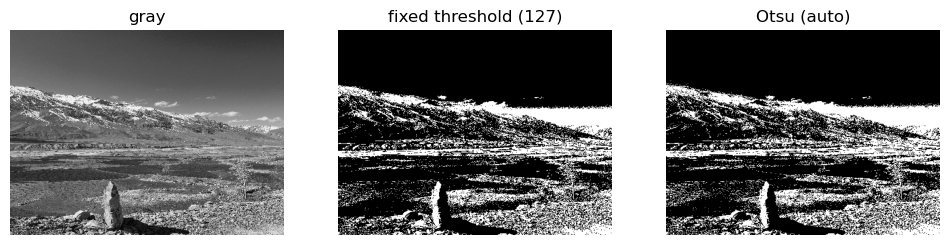

In [6]:
_, fixed = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
otsu_val, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print('otsu picked the cutoff', otsu_val)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(gray, cmap='gray');  plt.title('gray'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(fixed, cmap='gray'); plt.title('fixed threshold (127)'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(otsu, cmap='gray');  plt.title('Otsu (auto)'); plt.axis('off')
plt.show()

**Adaptive thresholding** picks a diffrent cutoff for each small area, so it handles uneven lighting much better than one global number.

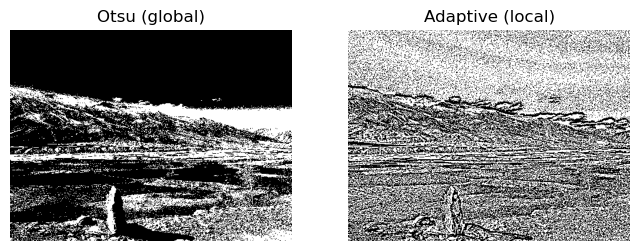

In [12]:
adapt = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                              cv2.THRESH_BINARY, 11, 2)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(otsu, cmap='gray');  plt.title('Otsu (global)'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(adapt, cmap='gray'); plt.title('Adaptive (local)'); plt.axis('off')
plt.show()

## edge based

instead of regions, find the boundaries. **Canny** looks for sharp intensity changes and traces them into thin edges.

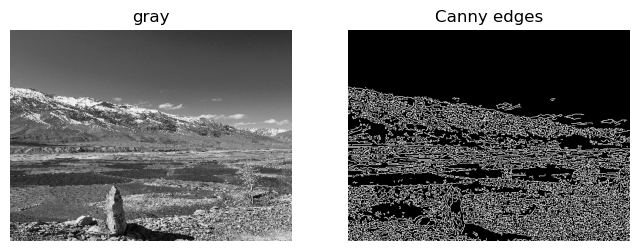

In [8]:
edges = cv2.Canny(gray, 100, 200)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(gray, cmap='gray');  plt.title('gray'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(edges, cmap='gray'); plt.title('Canny edges'); plt.axis('off')
plt.show()

## region based

clean up an Otsu mask with morphology, then a **distance transform** lights up the centre of each blob (far from the background), wich gives solid region cores.

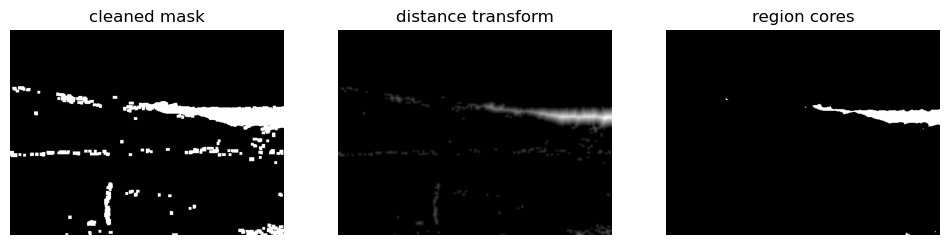

In [9]:
kernel = np.ones((3, 3), np.uint8)
opened = cv2.morphologyEx(otsu, cv2.MORPH_OPEN, kernel, iterations=2)

dist = cv2.distanceTransform(opened, cv2.DIST_L2, 5)
_, cores = cv2.threshold(dist, 0.3 * dist.max(), 255, 0)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(opened, cmap='gray'); plt.title('cleaned mask'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(dist, cmap='gray');   plt.title('distance transform'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(cores, cmap='gray');  plt.title('region cores'); plt.axis('off')
plt.show()

## colour based (k means)

this one groups pixels by colour instead of brightness. k means clusters every pixel into k colours, so the image gets posterised into k regions.

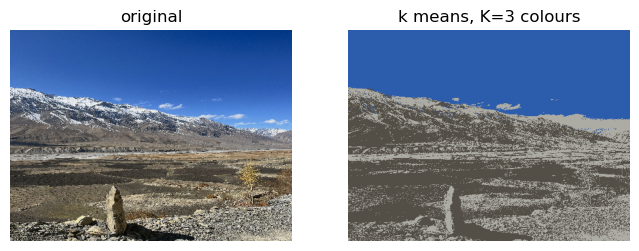

In [10]:
Z = img.reshape((-1, 3)).astype(np.float32)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3
_, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

seg = centers[labels.flatten()].astype(np.uint8).reshape(img.shape)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(img);  plt.title('original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(seg);  plt.title(f'k means, K={K} colours'); plt.axis('off')
plt.show()

### quick recap

thresholding splits by intensity (Otsu and adaptive are the smarter versions), Canny splits by edges, the distance transform gives solid region cores, and k means splits by colour. diffrent jobs need diffrent methods.